In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks, peak_widths,resample,correlate, correlation_lags,peak_prominences,resample,butter, lfilter, freqz,medfilt
from scipy.stats import pearsonr,wilcoxon,mannwhitneyu,kruskal
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore
import scipy.io as spio

params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)
def format_ax(ax,xlim,ylim,xspace,yspace):
   

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))


In [2]:
### Function to convert matlab struct to python dictionary, adapted from https://stackoverflow.com/questions/7008608/scipy-io-loadmat-nested-structures-i-e-dictionaries
def loadmat(filename):
    '''
    this function should be called instead of direct spio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    '''
    def _check_keys(d):
        '''
        checks if entries in dictionary are mat-objects. If yes
        todict is called to change them to nested dictionaries
        '''
        for key in d:
            if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
                d[key] = _todict(d[key])
        return d

    def _todict(matobj):
        '''
        A recursive function which constructs from matobjects nested dictionaries
        '''
        d = {}
        for strg in matobj._fieldnames:
            elem = matobj.__dict__[strg]
            if isinstance(elem, spio.matlab.mio5_params.mat_struct):
                d[strg] = _todict(elem)
            elif isinstance(elem, np.ndarray):
                d[strg] = _tolist(elem)
            else:
                d[strg] = elem
        return d

    def _tolist(ndarray):
        '''
        A recursive function which constructs lists from cellarrays
        (which are loaded as numpy ndarrays), recursing into the elements
        if they contain matobjects.
        '''
        elem_list = []
        for sub_elem in ndarray:
            if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
                elem_list.append(_todict(sub_elem))
            elif isinstance(sub_elem, np.ndarray):
                elem_list.append(_tolist(sub_elem))
            else:
                elem_list.append(sub_elem)
        return elem_list
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

In [3]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [28]:
### Helper functions for heartrate analysis
def map_voltage(rates,out_max = 5):
    in_min = 0
    in_max = 1023
    out_min = 0
    return [(x - in_min) * (out_max - out_min) / (in_max - in_min) + out_min for x in rates]

def remove_err(hr,err, allowed = [0,3,4,7]):
    return [x if err[i] in allowed else np.nan for i,x in enumerate(hr)]

In [4]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [ ]:
### Get data for FigS6A
id_date = { 
"004106" : ["20230908"],
"004155" : ["20230908"],
"004107" : ["20230908"],
"004105" : ["20230728"],
"004103" : ["20230728"],
"004104" : ["20230728"]
}

sess =1
pre = 10
post = 10
df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        face_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        data = mat_data["response"]["sessdata"]
        laser_times = mat_data["response"]["laser_time"]
        laser_itis = mat_data["response"]["trial_iti"]
        laser_widths = mat_data["response"]["trial_pulse_width"]
        laser_freqs = [np.round((width/(iti + width)) * 100) for iti,width in zip(laser_itis,laser_widths)]
        trans = np.transpose(data)
        ard_times = trans[4]
        wheel = trans[3]
        wheel[0] = 0
        wheel = zscore(np.interp(times,ard_times,wheel))
        diffs = np.array(pd.read_csv(face_path)["Facial Movement"])
    
        wheel_snips,wheel_peri_times = trial_align(laser_times,times,wheel, pre = pre, post = post)
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        face_snips,face_peri_times = trial_align(laser_times,times,diffs, pre = pre, post = post)


        for j,trial in enumerate(wheel_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(wheel_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "wheel", "ID" : id, "date" : date,"sess":sess,"frequency":str(int(laser_freqs[j]))}
                df_list.append(new_dict)

        for j,trial in enumerate(pupil_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(pupil_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "pupil", "ID" : id, "date" : date,"sess":sess,"frequency":str(int(laser_freqs[j]))}
                df_list.append(new_dict)

        for j,trial in enumerate(face_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(face_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "face", "ID" : id, "date" : date,"sess":sess,"frequency":str(int(laser_freqs[j]))}
                df_list.append(new_dict)

opto_df = pd.DataFrame.from_dict(df_list)

004106 20230908


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004155 20230908


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/3888750071.py:57: RuntimeWarning: Mean of empty slice
  baseline = np.nanmean(trial

004107 20230908


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004103 20230728


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004104 20230728


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


In [ ]:
### Get data for FigS6B, S6C, S6D
id_date = { 
"004106" : ["20230908"],
"004155" : ["20230908"],
"004107" : ["20230908"],
"004105" : ["20230728"],
"004103" : ["20230728"],
"004104" : ["20230728"]
}

sess =1
pre = 10
post = 10
df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        face_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        data = mat_data["response"]["sessdata"]
        laser_times = mat_data["response"]["laser_time"]
        laser_itis = mat_data["response"]["trial_iti"]
        laser_widths = mat_data["response"]["trial_pulse_width"]
        laser_freqs = [np.round((width/(iti + width)) * 100) for iti,width in zip(laser_itis,laser_widths)]
        trans = np.transpose(data)
        ard_times = trans[4]
        wheel = trans[3]
        wheel[0] = 0
        wheel = zscore(np.interp(times,ard_times,wheel))
        diffs = np.array(pd.read_csv(face_path)["Facial Movement"])
    
        wheel_snips,wheel_peri_times = trial_align(laser_times,times,wheel, pre = pre, post = post)
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        face_snips,face_peri_times = trial_align(laser_times,times,diffs, pre = pre, post = post)


        for j,trial in enumerate(wheel_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])
            new_dict = {"Delta" : post_laser-pre_laser,"ID" : id,'type':"wheel","Date":date,"trial":j,"frequency":str(int(laser_freqs[j]))}
            df_list.append(new_dict)
          

        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])
            new_dict = {"Delta" : post_laser-pre_laser,"ID" : id,'type':"pupil","Date":date,"trial":j,"frequency":str(int(laser_freqs[j]))}
            df_list.append(new_dict)
      

        for j,trial in enumerate(face_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[200:220])
            new_dict = {"Delta" : post_laser-pre_laser,"ID" : id,'type':"face","Date":date,"trial":j,"frequency":str(int(laser_freqs[j]))}
            df_list.append(new_dict)
      

freq_delta_df = pd.DataFrame.from_dict(df_list)

004106 20230908


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004155 20230908


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/3819679044.py:57: RuntimeWarning: Mean of empty slice
  pre_laser = np.nanmean(tria

004107 20230908


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004103 20230728


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004104 20230728


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/13312837.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = opto_df.query("type == 'pupil'").groupby(["ID","type","Time from Laser (s)","frequency"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1,hue = "frequency",legend = None,palette = ["mediumblue","midnightblue","skyblue","dodgerblue"])


Text(0, 0.5, 'Pupil Size (z-scr)')

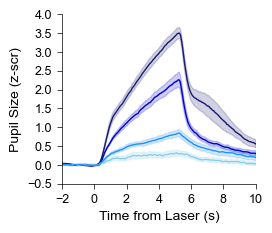

In [ ]:
### Plot FigS6A
plt.figure(figsize = (2.5,2.2))
ax = sns.lineplot(data = opto_df.query("type == 'pupil'").groupby(["ID","type","Time from Laser (s)","frequency"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1,hue = "frequency",legend = None,palette = ["mediumblue","midnightblue","skyblue","dodgerblue"])
format_ax(ax,[-2,10],[-0.5,4],2,0.5)
ax.set_xlabel("Time from Laser (s)")
ax.set_ylabel("Pupil Size (z-scr)")


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/617170491.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = freq_delta_df.query("type == 'pupil'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue",order = ["3","5","10","20"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/617170491.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = freq_delta_df.query("type == 'pupil'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency",

Text(0.5, 0, 'Laser Freq. (Hz)')

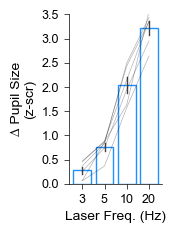

In [21]:
### Plot FigS6B

plt.figure(figsize = (1.2,2.2))
g = sns.barplot(data = freq_delta_df.query("type == 'pupil'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue",order = ["3","5","10","20"])
sns.lineplot(data = freq_delta_df.query("type == 'pupil'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[4:]:
    y1,y2,y3,y4 = line.get_ydata()
    line.set_ydata([y3,y4,y1,y2])
g.set_yticks(np.arange(0,4,0.5))
g.set(ylim=(0, 3.5))
g.set_ylabel("∆ Pupil Size\n(z-scr)")
g.set_xlabel("Laser Freq. (Hz)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/2982295049.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = freq_delta_df.query("type == 'wheel'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "darkorange",order = ["3","5","10","20"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/2982295049.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = freq_delta_df.query("type == 'wheel'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency

Text(0.5, 0, 'Laser Freq. (Hz)')

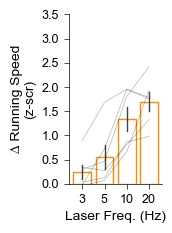

In [ ]:
### Plot FigS6C

plt.figure(figsize = (1.2,2.2))
g = sns.barplot(data = freq_delta_df.query("type == 'wheel'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "darkorange",order = ["3","5","10","20"])
sns.lineplot(data = freq_delta_df.query("type == 'wheel'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[4:]:
    y1,y2,y3,y4 = line.get_ydata()
    line.set_ydata([y3,y4,y1,y2])
g.set_yticks(np.arange(0,4,0.5))
g.set(ylim=(0, 3.5))
g.set_ylabel("∆ Running Speed\n(z-scr)")
g.set_xlabel("Laser Freq. (Hz)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/4017508159.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = freq_delta_df.query("type == 'face'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple",order = ["3","5","10","20"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/4017508159.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = freq_delta_df.query("type == 'face'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y =

Text(0.5, 0, 'Laser Freq. (Hz)')

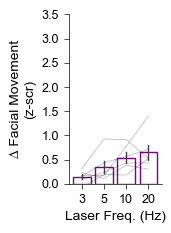

In [ ]:
### Plot FigS6D

plt.figure(figsize = (1.2,2.2))
g = sns.barplot(data = freq_delta_df.query("type == 'face'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple",order = ["3","5","10","20"])
sns.lineplot(data = freq_delta_df.query("type == 'face'").groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[4:]:
    y1,y2,y3,y4 = line.get_ydata()
    line.set_ydata([y3,y4,y1,y2])
g.set_yticks(np.arange(0,4,0.5))
g.set(ylim=(0, 3.5))
g.set_ylabel("∆ Facial Movement\n(z-scr)")
g.set_xlabel("Laser Freq. (Hz)")

In [14]:
### Get data for FigS6E

id_date = { 
"004103" : ["20230801"],
"004104" : ["20230801"],
"004105" : ["20230801"],
"004155" : ["20230913"],
"004106" : ["20230913"],
"004107" : ["20230913"]
}

sess =1
pre = 10
post = 10
df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        face_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        data = mat_data["response"]["sessdata"]
        laser_times = mat_data["response"]["laser_time"]
        laser_durs = mat_data["response"]["trial_dur"]
        trans = np.transpose(data)
        ard_times = trans[4]
        wheel = trans[3]
        wheel[0] = 0
        wheel = zscore(np.interp(times,ard_times,wheel))
        diffs = np.array(pd.read_csv(face_path)["Facial Movement"])
    
        wheel_snips,wheel_peri_times = trial_align(laser_times,times,wheel, pre = pre, post = post)
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        face_snips,face_peri_times = trial_align(laser_times,times,diffs, pre = pre, post = post)


        for j,trial in enumerate(wheel_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(wheel_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "wheel", "ID" : id, "date" : date,"sess":sess,"duration":str(int(laser_durs[j])/1000)}
                df_list.append(new_dict)

        for j,trial in enumerate(pupil_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(pupil_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "pupil", "ID" : id, "date" : date,"sess":sess,"duration":str(int(laser_durs[j])/1000)}
                df_list.append(new_dict)

        for j,trial in enumerate(face_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(face_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "face", "ID" : id, "date" : date,"sess":sess,"duration":str(int(laser_durs[j])/1000)}
                df_list.append(new_dict)

dur_df = pd.DataFrame.from_dict(df_list)

004103 20230801


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004104 20230801


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004105 20230801


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004106 20230913


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004107 20230913


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


In [20]:
### Get data for FigS6F, S6G, S6H

id_date = { 
"004103" : ["20230801"],
"004104" : ["20230801"],
"004105" : ["20230801"],
"004155" : ["20230913"],
"004106" : ["20230913"],
"004107" : ["20230913"]
}

sess =1
pre = 10
post = 10
df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        face_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        data = mat_data["response"]["sessdata"]
        laser_times = mat_data["response"]["laser_time"]
        laser_durs = mat_data["response"]["trial_dur"]
        trans = np.transpose(data)
        ard_times = trans[4]
        wheel = trans[3]
        wheel[0] = 0
        wheel = zscore(np.interp(times,ard_times,wheel))
        diffs = np.array(pd.read_csv(face_path)["Facial Movement"])
    
        wheel_snips,wheel_peri_times = trial_align(laser_times,times,wheel, pre = pre, post = post)
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        face_snips,face_peri_times = trial_align(laser_times,times,diffs, pre = pre, post = post)


        for j,trial in enumerate(wheel_snips):
            pre_laser = np.nanmean(trial[160:200])
            duration_frames = int((laser_durs[j]/1000) *20)
            post_laser = np.nanmean(trial[200 + (duration_frames-5):200 + duration_frames])
            new_dict = {"Delta" : post_laser-pre_laser,"ID" : id,'type':"wheel","Date":date,"trial":j,"duration":str(int(laser_durs[j])/1000)}
            df_list.append(new_dict)
          

        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])
            duration_frames = int((laser_durs[j]/1000) *20)
            post_laser = np.nanmean(trial[200 + (duration_frames-5):200 + duration_frames])
            new_dict = {"Delta" : post_laser-pre_laser,"ID" : id,'type':"pupil","Date":date,"trial":j,"duration":str(int(laser_durs[j])/1000)}
            df_list.append(new_dict)
      

        for j,trial in enumerate(face_snips):
            pre_laser = np.nanmean(trial[160:200])
            duration_frames = int((laser_durs[j]/1000) *20)
            post_laser = np.nanmean(trial[200 + (duration_frames-5):200 + duration_frames])

            new_dict = {"Delta" : post_laser-pre_laser,"ID" : id,'type':"face","Date":date,"trial":j,"duration":str(int(laser_durs[j])/1000)}
            df_list.append(new_dict)
      
dur_delta_df = pd.DataFrame.from_dict(df_list)

004103 20230801


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004104 20230801


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004105 20230801


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004106 20230913


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004107 20230913


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/429267722.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = dur_df.query("type == 'pupil'").query("duration != '0.05'",engine = "python").groupby(["ID","type","Time from Laser (s)","duration"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1,hue = "duration",legend = None,palette = ["dodgerblue","mediumblue","midnightblue"])


Text(0, 0.5, 'Pupil Size (z-scr)')

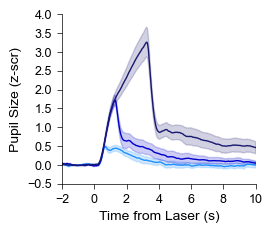

In [22]:
### Plot FigS6E

plt.figure(figsize = (2.5,2.2))
ax = sns.lineplot(data = dur_df.query("type == 'pupil'").query("duration != '0.05'",engine = "python").groupby(["ID","type","Time from Laser (s)","duration"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1,hue = "duration",legend = None,palette = ["dodgerblue","mediumblue","midnightblue"])
format_ax(ax,[-2,10],[-0.5,4],2,0.5)
ax.set_xlabel("Time from Laser (s)")
ax.set_ylabel("Pupil Size (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581788849.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'pupil'").groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581788849.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'pupil'").groupb

Text(0.5, 0, 'Stim duration (s)')

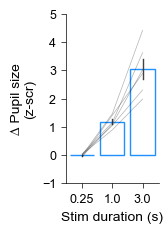

In [23]:
### Plot FigS6F

plt.figure(figsize = (1.2,2.2))
g = sns.barplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'pupil'").groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
sns.lineplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'pupil'").groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.set_yticks(np.arange(-1,6,1))
g.set(ylim=(-1, 5))
g.set_ylabel("∆ Pupil size\n(z-scr)")
g.set_xlabel("Stim duration (s)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/3177151710.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'wheel'").groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "darkorange")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/3177151710.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'wheel'").grou

Text(0.5, 0, 'Stim duration (s)')

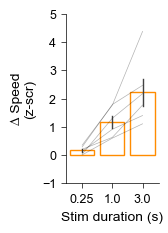

In [24]:
### Plot FigS6G

plt.figure(figsize = (1.2,2.2))
g = sns.barplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'wheel'").groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "darkorange")
sns.lineplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'wheel'").groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.set_yticks(np.arange(-1,6,1))
g.set(ylim=(-1, 5))
g.set_ylabel("∆ Speed\n(z-scr)")
g.set_xlabel("Stim duration (s)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/3171920509.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'face'").groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/3171920509.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'face'").groupby(["

Text(0.5, 0, 'Stim duration (s)')

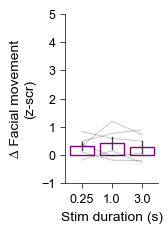

In [25]:
### Plot FigS6H

plt.figure(figsize = (1.2,2.2))
g = sns.barplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'face'").groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple")
sns.lineplot(data = dur_delta_df.query("duration != '0.05'",engine = "python").query("type == 'face'").groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.set_yticks(np.arange(-1,6,1))
g.set(ylim=(-1, 5))
g.set_ylabel("∆ Facial movement\n(z-scr)")
g.set_xlabel("Stim duration (s)")

In [30]:
### Function to align HR data to opto stimulation

def hr_align_freq(id,date,sess): 
    pre = 5
    post = 25
    hr_scalar = 200
    err_scalar = 4
    hr_offset = 1.57
    hr_vol = 4.95
    matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
    mat_data = loadmat(matpath)["data"]
    laser_times = mat_data["response"]["laser_time"]
    data = mat_data["response"]["sessdata"]
    laser_itis = mat_data["response"]["trial_iti"]
    laser_widths = mat_data["response"]["trial_pulse_width"]
    laser_freqs = [np.round((width/(iti + width)) * 100) for iti,width in zip(laser_itis,laser_widths)]
    trans = np.transpose(data)
    ard_times = trans[4]
    hr_time = np.array([(x-hr_offset) for x in trans[4]])
    hr_time = hr_time[np.where(hr_time>=0)]
    converted_hr = [x * hr_scalar for x in map_voltage(trans[1],hr_vol)]
    errors = [np.round((x * err_scalar)) for x in map_voltage(trans[2],hr_vol)]
    final_hr = np.array(remove_err(converted_hr,errors))
    final_hr = final_hr[np.where(hr_time>=0)]
    hr_snips,hr_peri_times = trial_align(laser_times,hr_time,final_hr,pre = pre, post = post)
    error_prob = np.array([0 if x == 0 else 1 for x in errors])
    error_prob = error_prob[np.where(hr_time>=0)]
    error_snips,error_peri_times = trial_align(laser_times,hr_time,error_prob,pre = pre, post = post)
    df_list = []
    for j,trial in enumerate(hr_snips):
        if  np.count_nonzero(np.isnan(trial)) <100:
            for i,time in enumerate(hr_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "hr", "ID" : id, "date" : date,"sess":sess,"frequency":laser_freqs[j]}
                df_list.append(new_dict)
    df = pd.DataFrame.from_dict(df_list)

    return df

## Get data for FigS6I
hr_opto_df = pd.concat([hr_align_freq("004103","20230720","1"),hr_align_freq("004104","20230720","2"),hr_align_freq("004104","20230720","1"),hr_align_freq("004103","20230719","1"),hr_align_freq("004105","20230720","1"),hr_align_freq("004105","20230720","2"),hr_align_freq("004105","20230721","1")]).reset_index()


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.mat

In [32]:
### Function to calculate pre-stim and post-stim HR values

def hr_align_bar(id,date,sess):
    pre = 2
    post = 14
    hr_scalar = 200
    err_scalar = 4
    hr_offset = 1.57
    hr_vol = 4.95
    matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
    mat_data = loadmat(matpath)["data"]
    laser_times = mat_data["response"]["laser_time"]
    data = mat_data["response"]["sessdata"]
    laser_itis = mat_data["response"]["trial_iti"]
    laser_widths = mat_data["response"]["trial_pulse_width"]
    laser_freqs = [np.round((width/(iti + width)) * 100) for iti,width in zip(laser_itis,laser_widths)]
    trans = np.transpose(data)
    ard_times = trans[4]
    hr_time = np.array([(x-hr_offset) for x in trans[4]])
    hr_time = hr_time[np.where(hr_time>=0)]
    converted_hr = [x * hr_scalar for x in map_voltage(trans[1],hr_vol)]
    errors = [np.round((x * err_scalar)) for x in map_voltage(trans[2],hr_vol)]
    final_hr = np.array(remove_err(converted_hr,errors))
    final_hr = final_hr[np.where(hr_time>=0)]
    hr_snips,hr_peri_times = trial_align(laser_times,hr_time,final_hr,pre = pre, post = post)
    error_prob = np.array([0 if x == 0 else 1 for x in errors])
    error_prob = error_prob[np.where(hr_time>=0)]
    error_snips,error_peri_times = trial_align(laser_times,hr_time,error_prob,pre = pre, post = post)
    df_list = []
    for j,trial in enumerate(hr_snips):
        if  np.count_nonzero(np.isnan(trial)) <100:
            pre_laser = np.nanmean(trial[0:40])
            post_laser = np.nanmean(trial[100:140])
            new_dict = {"trial" : j, "value" :pre_laser,"laser" :"pre","type" : "hr", "ID" : id, "date" : date,"sess":sess,"frequency":laser_freqs[j]}
            df_list.append(new_dict)
            new_dict = {"trial" : j, "value" :post_laser,"laser" :"post","type" : "hr", "ID" : id, "date" : date,"sess":sess,"frequency":laser_freqs[j]}
            df_list.append(new_dict)
    df = pd.DataFrame.from_dict(df_list)

    return df

### Get data for FigS6J
hr_bar_df = pd.concat([hr_align_bar("004103","20230720","1"),hr_align_bar("004104","20230720","2"),hr_align_bar("004104","20230720","1"),hr_align_bar("004103","20230719","1"),hr_align_bar("004105","20230720","1"),hr_align_bar("004105","20230720","2"),hr_align_bar("004105","20230721","1")]).reset_index()


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_13260/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.mat

Text(0, 0.5, 'HR (bpm)')

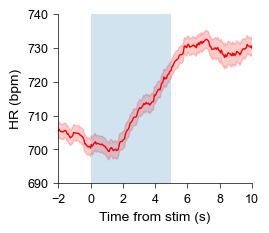

In [ ]:
### Plot FigS6I

plt.figure(figsize = (2.5,2.2))
ax = sns.lineplot(data = hr_opto_df.query("frequency == 20"), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "red",linewidth = 1)
ax.axvspan(0,5,alpha = 0.2)
format_ax(ax,[-2,10],[690,740],2,10)
ax.set_xlabel("Time from stim (s)")
ax.set_ylabel("HR (bpm)")


Text(0, 0.5, 'HR (bpm)')

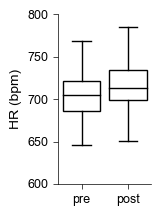

In [33]:
### Plot FigS6J

plt.figure(figsize = (1.2,2.2))
g = sns.boxplot(data = hr_bar_df.query("frequency == 20").dropna(), x = "laser", y = "value",linewidth=1,fliersize= 0)
# iterate over boxes
for i,box in enumerate(g.patches):
    box.set_edgecolor('black')
    box.set_facecolor('white')

    # iterate over whiskers and median lines
    for j in range(6*i,6*(i+1)):
         g.lines[j].set_color('black')
g.set_yticks(np.arange(600,850,50))
g.set(ylim=(600,800))
g.xaxis.label.set_visible(False)
g.set_ylabel("HR (bpm)")